# Batch EDF -> BIDS + QC + event masks — **all legacy (2018-2019) subjects**

Combines the two single-purpose notebooks into one batch pass over **every** subject folder in the legacy `2. ET_3T_Data/` tree:
- from `7-MREyeTrack_recording_inspect_olddata.ipynb`: the EDF->BIDS conversion (newer-pyedfread adaptation) and the recording QC.
- from `8-MREyeTrack_batch_masks.ipynb`: the per-subject loop and the four mutually-exclusive event masks saved as `.mat`.

For each subject folder it:
1. converts the `.edf` to a BIDS `*.tsv.gz` + `*.json` (skipped if already present),
2. loads the recording (headerless; column names from the sidecar),
3. computes a QC report (duration, timing gaps, dead columns, missing fractions),
4. builds the four fine-grained masks (**blink > saccade > fixation > tracking-loss**),
5. **saves all outputs into that subject's own folder**, and
6. writes a cross-subject summary CSV + figure at the tree root.

No MRI-window trimming is applied — this is free-viewing legacy data, not the fixation-grid study, so the full recording is used and no gaze-direction binning is done.

**Kernel: `mreyetrack`.**

### Outputs per subject folder
| File | Meaning |
|---|---|
| `<stem>_recording-eyetrack_physio.tsv.gz` / `.json` | BIDS recording + sidecar |
| `<stem>_fixation_ok_mask.mat` | fixation=1 with valid coordinates |
| `<stem>_saccade_only_mask.mat` | saccade=1 without blink |
| `<stem>_blink_event_mask.mat` | blink (sub-event of saccade) |
| `<stem>_tracking_loss_mask.mat` | unlabeled / tracking loss / gaps |
| `<stem>_qc_summary.json` | per-subject QC report |
| `<stem>_qc_overview.png` | gaze density + mask composition figure |

In [1]:
import sys, json, warnings, glob
from pathlib import Path
import numpy as np
import pandas as pd
import scipy.io as sio
import matplotlib
import matplotlib.pyplot as plt

CODE_DIR = Path('/home/debi/jaime/repos/MR-EyeTrack/eye_tracker/hcph-sops-fork/code/eyetracking_MREyeTrack')
sys.path.insert(0, str(CODE_DIR))
from pyedfread import read_edf
from eyetrackingrun import EyeTrackingRun, write_bids

pd.set_option('display.width', 220, 'display.max_columns', 60)
SENTINEL = -32768  # EyeLink missing-value marker

## Config

In [2]:
LEGACY_ROOT = Path(
    '/mnt/filer01/MatTechLab/benedetta.franceschiello/_backup_filerch/Benedetta_Franceschiello/'
    '1_MR_Eye_Retina/8_Results/1_Motion_resolved_MR_Eye_3T/1_Motion_Resolved_Anatomical_GRE/'
    '2_Eye_Tracker_Results_Anatomical/2. ET_3T_Data'
)

# legacy free-viewing paradigm markers used as start/stop triggers (no hello/bye)
FIRST_TRIGGER = 'TRIALID'
LAST_TRIGGER = 'TRIAL_RESULT'

FORCE_RECONVERT = False   # True = re-run EDF->BIDS even if the .tsv.gz already exists
EXCLUDE_DIRS = {'_old'}

# One EDF per subject folder; folder name is like '20181113_exp_jr'
subject_dirs = sorted(
    d for d in LEGACY_ROOT.iterdir()
    if d.is_dir() and d.name not in EXCLUDE_DIRS and list(d.glob('*.edf'))
)
print(f'Found {len(subject_dirs)} subject folders:')
for d in subject_dirs:
    print('  ', d.name, '->', d.glob('*.edf').__next__().name)

Found 11 subject folders:
   20181113_exp_jr -> 1s1311.edf
   20181113_exp_mo -> 2s1311.edf
   20190225_exp_bm -> 250219bm.edf
   20190225_exp_nn -> 250219nn.edf
   20190228_exp_em -> em280219.edf
   20190228_exp_nt -> nt280219.edf
   20190301_exp_gr -> 190301gr.edf
   20190320_exp_am -> am190320.edf
   20190320_exp_kg -> kg190320.edf
   20190325_exp_la -> 190325la.edf
   20190325_exp_psr -> 190325ps.edf


## Helpers

In [3]:
def subject_label(folder):
    """'20181113_exp_jr' -> 'jr'."""
    return folder.name.rsplit('_', 1)[-1]


def convert_edf_to_bids(edf_path, force=False):
    """Convert one legacy EDF to a BIDS tsv.gz + json in the EDF's folder.
    Returns (tsv_path, json_path). Skips conversion if outputs already exist."""
    folder = edf_path.parent
    existing = sorted(folder.glob('*recording-eyetrack_physio.tsv.gz'))
    if existing and not force:
        tsv = existing[0]
        return tsv, tsv.with_name(tsv.name.replace('.tsv.gz', '.json'))

    samples, events, messages = read_edf(str(edf_path), trial_marker='')
    # adapt newer pyedfread output to the legacy EyeTrackingRun constructor
    messages = messages.rename(columns={'message': 'trialid', 'time': 'trialid_time'})
    events = events.rename(columns={'contains_blink': 'blink'})
    samples = samples.reset_index(drop=True)

    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        et = EyeTrackingRun(
            recording=samples, events=events, messages=messages,
            message_first_trigger=FIRST_TRIGGER, message_last_trigger=LAST_TRIGGER,
        )

    # write_bids names outputs after the reference file and drops its suffix
    ref = folder / f'{edf_path.stem}_task-fixation_bold.nii.gz'
    ref.touch()
    tsv, js = write_bids(et, ref)
    ref.unlink()  # remove the empty placeholder
    return Path(tsv), Path(js)


def load_recording(tsv_path, json_path):
    metadata = json.loads(Path(json_path).read_text())
    recording = pd.read_csv(
        tsv_path, sep='\t', header=None, names=metadata['Columns'], na_values='n/a',
    )
    return recording, metadata

In [4]:
def compute_masks(recording):
    """Four mutually-exclusive event masks over the full recording."""
    orig_nan = recording['x_coordinate'].isna() | recording['y_coordinate'].isna()
    is_blink = recording['blink'].astype(bool)
    is_saccade_only = recording['saccade'].astype(bool) & ~is_blink
    is_fixation_ok = recording['fixation'].astype(bool) & ~is_saccade_only & ~is_blink & ~orig_nan
    is_tracking_loss = ~is_blink & ~is_saccade_only & ~is_fixation_ok
    masks = {
        'fixation_ok':   is_fixation_ok.astype(int).to_numpy(),
        'saccade_only':  is_saccade_only.astype(int).to_numpy(),
        'blink_event':   is_blink.astype(int).to_numpy(),
        'tracking_loss': is_tracking_loss.astype(int).to_numpy(),
    }
    return masks


def qc_report(recording, metadata):
    n = len(recording)
    nan_counts = recording.isna().sum()
    sentinel_counts = (recording == SENTINEL).sum()
    dead = [c for c in recording.columns if (nan_counts[c] + sentinel_counts[c]) >= n]
    ts = recording['timestamp'].to_numpy()
    dts = np.diff(ts)
    fs = metadata['SamplingFrequency']
    xy_nan = int((recording['x_coordinate'].isna() | recording['y_coordinate'].isna()).sum())
    return {
        'n_samples': int(n),
        'duration_s': round(float((ts[-1] - ts[0]) / fs), 1),
        'sampling_freq': fs,
        'recorded_eye': metadata.get('RecordedEye'),
        'calib_quality': metadata.get('CalibrationResultQuality'),
        'calib_avg_err': metadata.get('AverageCalibrationError'),
        'calib_max_err': metadata.get('MaximalCalibrationError'),
        'n_timing_gaps': int((dts != 1).sum()),
        'max_gap_ms': int(dts.max()),
        'pct_xy_missing': round(100 * xy_nan / n, 2),
        'dead_columns': dead,
    }


def save_overview_figure(recording, masks, metadata, label, out_png):
    n = len(recording)
    screen_w = metadata['ScreenAOIDefinition'][1][1]
    screen_h = metadata['ScreenAOIDefinition'][1][3]
    # fixation-only gaze, clipped to screen
    fx = masks['fixation_ok'].astype(bool)
    d = recording.loc[fx, ['x_coordinate', 'y_coordinate']].dropna()
    d = d[d.x_coordinate.between(0, screen_w) & d.y_coordinate.between(0, screen_h)]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    if len(d):
        hb = axes[0].hexbin(d.x_coordinate, d.y_coordinate, gridsize=50,
                            extent=(0, screen_w, 0, screen_h), cmap='magma', mincnt=1)
        fig.colorbar(hb, ax=axes[0], label='samples')
    axes[0].invert_yaxis(); axes[0].invert_xaxis()
    axes[0].set_xlabel('x [px]'); axes[0].set_ylabel('y [px]')
    axes[0].set_title(f'{label}: fixation gaze density')

    names = ['fixation_ok', 'saccade_only', 'blink_event', 'tracking_loss']
    colors = ['#2ca02c', '#d62728', '#ff7f0e', '#7f7f7f']
    pct = [100 * masks[k].sum() / n for k in names]
    axes[1].bar(names, pct, color=colors)
    axes[1].set_ylabel('% of recording'); axes[1].set_ylim(0, 100)
    axes[1].set_title(f'{label}: event mask composition')
    axes[1].tick_params(axis='x', rotation=30)
    for i, v in enumerate(pct):
        axes[1].text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=8)
    fig.tight_layout()
    fig.savefig(out_png, dpi=110)
    plt.close(fig)

In [5]:
def process_subject(folder, force=False):
    label = subject_label(folder)
    print(f"\n{'='*60}\nProcessing {folder.name}  (label: {label})")
    edf = sorted(folder.glob('*.edf'))[0]

    tsv, js = convert_edf_to_bids(edf, force=force)
    print(f'  BIDS: {tsv.name}')
    recording, metadata = load_recording(tsv, js)
    file_name = tsv.name.replace('.tsv.gz', '')
    n = len(recording)
    print(f'  recording: {n} samples x {recording.shape[1]} cols | eye={metadata.get("RecordedEye")}')

    if metadata.get('RecordedEye') not in ('right', 'left'):
        print(f'  [SKIP] unexpected RecordedEye={metadata.get("RecordedEye")}')
        return None

    qc = qc_report(recording, metadata)
    print(f"  duration={qc['duration_s']}s gaps={qc['n_timing_gaps']} "
          f"xy_missing={qc['pct_xy_missing']}% dead_cols={len(qc['dead_columns'])}")

    masks = compute_masks(recording)
    total = sum(masks.values())
    assert (total == 1).all(), f'masks do not partition recording for {label}'

    # save masks (.mat)
    for name, arr in masks.items():
        sio.savemat(folder / f'{file_name}_{name}_mask.mat', {'array': arr})

    # save per-subject QC json
    qc_out = dict(qc)
    qc_out['subject'] = label
    qc_out['folder'] = folder.name
    qc_out['edf'] = edf.name
    qc_out.update({f'{k}_n': int(v.sum()) for k, v in masks.items()})
    qc_out.update({f'{k}_pct': round(100 * v.sum() / n, 2) for k, v in masks.items()})
    (folder / f'{file_name}_qc_summary.json').write_text(json.dumps(qc_out, indent=2))

    # save per-subject overview figure
    save_overview_figure(recording, masks, metadata, label,
                         folder / f'{file_name}_qc_overview.png')

    print(f'  Saved 4 masks + qc_summary.json + qc_overview.png -> {folder.name}/')
    for k, v in masks.items():
        print(f'    {k:<14}: {int(v.sum()):>8}  ({100*v.sum()/n:.1f}%)')

    row = {'subject': label, 'folder': folder.name, 'total': n,
           'duration_s': qc['duration_s'], 'pct_xy_missing': qc['pct_xy_missing'],
           'calib_quality': qc['calib_quality'], 'calib_avg_err': qc['calib_avg_err']}
    row.update({k: int(v.sum()) for k, v in masks.items()})
    return row

## Run the batch

In [6]:
all_stats = []
for folder in subject_dirs:
    try:
        row = process_subject(folder, force=FORCE_RECONVERT)
        if row is not None:
            all_stats.append(row)
    except Exception as e:
        print(f'  [ERROR] {folder.name}: {type(e).__name__}: {e}')

print(f'\nDone. Processed {len(all_stats)} / {len(subject_dirs)} subjects.')


Processing 20181113_exp_jr  (label: jr)
  BIDS: 1s1311_task-fixation_recording-eyetrack_physio.tsv.gz


  recording: 526639 samples x 25 cols | eye=right
  duration=530.4s gaps=105 xy_missing=0.51% dead_cols=6


  Saved 4 masks + qc_summary.json + qc_overview.png -> 20181113_exp_jr/
    fixation_ok   :   498203  (94.6%)
    saccade_only  :    23163  (4.4%)
    blink_event   :     4269  (0.8%)
    tracking_loss :     1004  (0.2%)

Processing 20181113_exp_mo  (label: mo)
  BIDS: 2s1311_task-fixation_recording-eyetrack_physio.tsv.gz


  recording: 526635 samples x 25 cols | eye=right
  duration=530.4s gaps=105 xy_missing=4.21% dead_cols=6


  Saved 4 masks + qc_summary.json + qc_overview.png -> 20181113_exp_mo/
    fixation_ok   :   436170  (82.8%)
    saccade_only  :    40899  (7.8%)
    blink_event   :    47924  (9.1%)
    tracking_loss :     1642  (0.3%)

Processing 20190225_exp_bm  (label: bm)
  BIDS: 250219bm_task-fixation_recording-eyetrack_physio.tsv.gz


...

  Saved 4 masks + qc_summary.json + qc_overview.png -> 20190320_exp_kg/
    fixation_ok   :   482611  (91.7%)
    saccade_only  :    32300  (6.1%)
    blink_event   :    10650  (2.0%)
    tracking_loss :      939  (0.2%)

Processing 20190325_exp_la  (label: la)
  BIDS: 190325la_task-fixation_recording-eyetrack_physio.tsv.gz


  recording: 526603 samples x 25 cols | eye=right
  duration=530.4s gaps=105 xy_missing=10.03% dead_cols=6


  Saved 4 masks + qc_summary.json + qc_overview.png -> 20190325_exp_la/
    fixation_ok   :   402741  (76.5%)
    saccade_only  :    32950  (6.3%)
    blink_event   :    88388  (16.8%)
    tracking_loss :     2524  (0.5%)

Processing 20190325_exp_psr  (label: psr)
  BIDS: 190325ps_task-fixation_recording-eyetrack_physio.tsv.gz


  recording: 526599 samples x 25 cols | eye=right
  duration=530.4s gaps=105 xy_missing=4.85% dead_cols=6


  Saved 4 masks + qc_summary.json + qc_overview.png -> 20190325_exp_psr/
    fixation_ok   :   444985  (84.5%)
    saccade_only  :    22148  (4.2%)
    blink_event   :    58132  (11.0%)
    tracking_loss :     1334  (0.3%)

Done. Processed 11 / 11 subjects.


## Cross-subject summary
Saved to the tree root as `batch_qc_summary.csv` and `batch_event_mask_composition.png`.

In [7]:
if not all_stats:
    print('No data to summarise.')
else:
    df = pd.DataFrame(all_stats).set_index('subject')
    csv_path = LEGACY_ROOT / 'batch_qc_summary.csv'
    df.to_csv(csv_path)
    print('Saved:', csv_path)
    display(df)

Saved: /mnt/filer01/MatTechLab/benedetta.franceschiello/_backup_filerch/Benedetta_Franceschiello/1_MR_Eye_Retina/8_Results/1_Motion_resolved_MR_Eye_3T/1_Motion_Resolved_Anatomical_GRE/2_Eye_Tracker_Results_Anatomical/2. ET_3T_Data/batch_qc_summary.csv


,folder,total,duration_s,pct_xy_missing,calib_quality,calib_avg_err,fixation_ok,saccade_only,blink_event,tracking_loss
subject,,,,,,,,,,
jr,20181113_exp_jr,526639,530.4,0.51,GOOD,0.37,498203,23163,4269,1004
mo,20181113_exp_mo,526635,530.4,4.21,GOOD,0.25,436170,40899,47924,1642
bm,20190225_exp_bm,526486,530.4,3.00,GOOD,0.23,476847,14104,34396,1139
nn,20190225_exp_nn,526523,530.4,0.36,GOOD,0.34,350031,166962,5398,4132
em,20190228_exp_em,526477,530.4,0.21,GOOD,0.44,478600,42163,4574,1140
nt,20190228_exp_nt,526474,530.4,1.45,GOOD,0.19,490693,20343,14070,1368
gr,20190301_exp_gr,526464,530.4,1.91,GOOD,0.49,485923,18884,20741,916
am,20190320_exp_am,526580,530.4,0.83,GOOD,0.43,504636,12610,8320,1014
kg,20190320_exp_kg,526500,530.4,0.72,GOOD,0.54,482611,32300,10650,939


Saved: /mnt/filer01/MatTechLab/benedetta.franceschiello/_backup_filerch/Benedetta_Franceschiello/1_MR_Eye_Retina/8_Results/1_Motion_resolved_MR_Eye_3T/1_Motion_Resolved_Anatomical_GRE/2_Eye_Tracker_Results_Anatomical/2. ET_3T_Data/batch_event_mask_composition.png


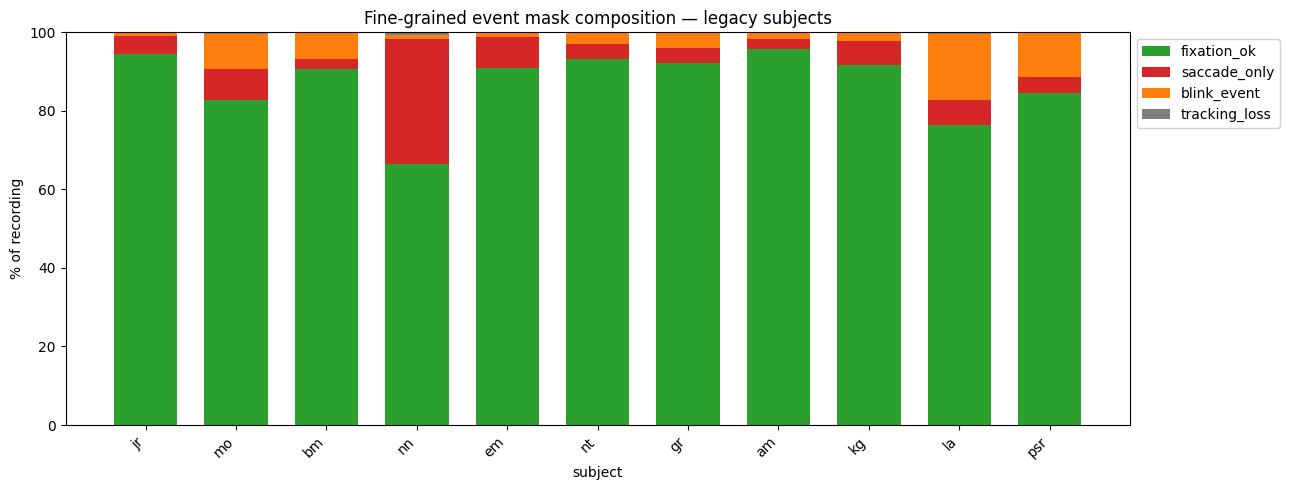

In [8]:
if all_stats:
    cats = ['fixation_ok', 'saccade_only', 'blink_event', 'tracking_loss']
    colors = ['#2ca02c', '#d62728', '#ff7f0e', '#7f7f7f']
    pct = df[cats].div(df['total'], axis=0) * 100

    fig, ax = plt.subplots(figsize=(13, 5))
    bottom = np.zeros(len(pct))
    for col, color in zip(cats, colors):
        ax.bar(pct.index, pct[col], bottom=bottom, label=col, color=color, width=0.7)
        bottom += pct[col].values
    ax.set_xlabel('subject'); ax.set_ylabel('% of recording'); ax.set_ylim(0, 100)
    ax.set_xticks(range(len(pct.index)))
    ax.set_xticklabels(pct.index, rotation=45, ha='right')
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1), framealpha=0.9)
    ax.set_title('Fine-grained event mask composition — legacy subjects')
    fig.tight_layout()
    fig_path = LEGACY_ROOT / 'batch_event_mask_composition.png'
    fig.savefig(fig_path, dpi=110)
    print('Saved:', fig_path)
    plt.show()